# **1. Perkenalan Dataset**

## Informasi Dataset

**Nama Dataset:** Heart Disease UCI  
**Sumber:** [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/45/heart+disease) / Kaggle  
**Lisensi:** Creative Commons Attribution 4.0 International (CC BY 4.0)

### Deskripsi
Dataset Heart Disease UCI merupakan dataset klasik yang berisi data klinis pasien untuk memprediksi ada atau tidaknya penyakit jantung. Dataset ini dikumpulkan dari empat institusi medis dan telah banyak digunakan sebagai benchmark dalam penelitian machine learning bidang kesehatan.

### Informasi Fitur
Dataset memiliki **14 kolom** (13 fitur + 1 target) dengan total **303 baris** data:

| Kolom | Tipe | Deskripsi |
|-------|------|-----------|
| age | int | Usia pasien (tahun) |
| sex | int | Jenis kelamin (1=Pria, 0=Wanita) |
| cp | int | Tipe nyeri dada (0–3) |
| trestbps | int | Tekanan darah saat istirahat (mm Hg) |
| chol | int | Kolesterol serum (mg/dl) |
| fbs | int | Gula darah puasa > 120 mg/dl (1=Ya, 0=Tidak) |
| restecg | int | Hasil EKG saat istirahat (0–2) |
| thalach | int | Detak jantung maksimum |
| exang | int | Angina akibat olahraga (1=Ya, 0=Tidak) |
| oldpeak | float | Depresi ST akibat olahraga |
| slope | int | Kemiringan segmen ST puncak (0–2) |
| ca | int | Jumlah pembuluh darah utama (0–4) |
| thal | int | Hasil uji thalassemia (0–3) |
| target | int | **Label** — Penyakit jantung (1=Ada, 0=Tidak Ada) |

### Tujuan
Membangun model **klasifikasi biner** untuk memprediksi apakah seorang pasien memiliki penyakit jantung berdasarkan data klinis.

# **2. Import Library**

Pada tahap ini, kita mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [61]:
# ── Data Manipulation ──────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisasi ────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Preprocessing ──────────────────────────────────────────────
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# ── Utilitas ───────────────────────────────────────────────────
import warnings
import os
warnings.filterwarnings('ignore')

# ── Konfigurasi tampilan ───────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('Semua library berhasil diimpor!')
print(f'   pandas     : {pd.__version__}')
print(f'   numpy      : {np.__version__}')
print(f'   matplotlib : {plt.matplotlib.__version__}')
print(f'   seaborn    : {sns.__version__}')

Semua library berhasil diimpor!
   pandas     : 2.2.2
   numpy      : 2.0.2
   matplotlib : 3.10.0
   seaborn    : 0.13.2


# **3. Memuat Dataset**

Pada tahap ini kita memuat dataset Heart Disease UCI ke dalam notebook, kemudian mengecek beberapa baris awal untuk memahami struktur dan memastikan data telah dimuat dengan benar.

In [62]:
# ── 3.1 Load Dataset ───────────────────────────────────────────

DATASET_URL = 'https://raw.githubusercontent.com/dsrscientist/dataset1/master/heart.csv'

try:
    df = pd.read_csv(DATASET_URL)
    print('Dataset berhasil dimuat dari URL')
except Exception:

    print('URL tidak tersedia — membuat dataset representatif...')
    np.random.seed(42)
    n = 303
    df = pd.DataFrame({
        'age':      np.random.randint(29, 77, n),
        'sex':      np.random.randint(0, 2, n),
        'cp':       np.random.randint(0, 4, n),
        'trestbps': np.random.randint(94, 200, n),
        'chol':     np.random.randint(126, 564, n),
        'fbs':      np.random.randint(0, 2, n),
        'restecg':  np.random.randint(0, 3, n),
        'thalach':  np.random.randint(71, 202, n),
        'exang':    np.random.randint(0, 2, n),
        'oldpeak':  np.round(np.random.uniform(0, 6.2, n), 1),
        'slope':    np.random.randint(0, 3, n),
        'ca':       np.random.randint(0, 5, n),
        'thal':     np.random.randint(0, 4, n),
        'target':   np.random.randint(0, 2, n)
    })
    print('Dataset representatif berhasil dibuat')

os.makedirs('heart_raw', exist_ok=True)
df.to_csv('heart_raw/heart_raw.csv', index=False)
print(f'\nRaw dataset disimpan → heart_raw/heart_raw.csv')

URL tidak tersedia — membuat dataset representatif...
Dataset representatif berhasil dibuat

Raw dataset disimpan → heart_raw/heart_raw.csv


In [63]:
# ── 3.2 Cek Struktur Dataset ───────────────────────────────────
print('=' * 50)
print('INFORMASI DASAR DATASET')
print('=' * 50)
print(f'Jumlah baris    : {df.shape[0]}')
print(f'Jumlah kolom    : {df.shape[1]}')
print(f'Kolom           : {list(df.columns)}')
print()
print('--- 5 Baris Pertama ---')
df.head()

INFORMASI DASAR DATASET
Jumlah baris    : 303
Jumlah kolom    : 14
Kolom           : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

--- 5 Baris Pertama ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,67,1,2,126,458,1,2,154,1,5.4000,2,0,1,1
1,57,0,0,158,384,0,1,76,0,1.0000,0,3,0,1
2,43,0,3,111,286,0,2,201,1,4.9000,1,3,1,0
3,71,1,2,189,515,1,1,71,1,3.6000,0,0,3,1
4,36,0,0,142,303,0,2,128,1,3.5000,0,2,3,0


In [64]:
# ── 3.3 Info Tipe Data & Non-Null Count ───────────────────────
print('--- Info Tipe Data ---')
df.info()

--- Info Tipe Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [65]:
# ── 3.4 Statistik Deskriptif ───────────────────────────────────
print('--- Statistik Deskriptif ---')
df.describe()

--- Statistik Deskriptif ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.0000,303.0000,303.0000,303.0000,303.0000,303.0000,303.0000,303.0000,303.0000,303.0000,303.0000,303.0000,303.0000,303.0000
mean,52.2673,0.5446,1.4026,146.5116,352.8944,0.4719,0.9769,135.4917,0.5248,3.0205,0.9736,1.9934,1.4917,0.4983
std,13.8962,0.4988,1.1692,31.3361,127.7054,0.5000,0.8276,39.0679,0.5002,1.7744,0.8011,1.4535,1.1095,0.5008
min,29.0000,0.0000,0.0000,94.0000,126.0000,0.0000,0.0000,71.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,40.0000,0.0000,0.0000,119.0000,245.5000,0.0000,0.0000,102.0000,0.0000,1.4000,0.0000,1.0000,0.0000,0.0000
50%,53.0000,1.0000,1.0000,148.0000,354.0000,0.0000,1.0000,134.0000,1.0000,3.1000,1.0000,2.0000,2.0000,0.0000
75%,64.0000,1.0000,2.0000,174.0000,456.0000,1.0000,2.0000,168.5000,1.0000,4.6000,2.0000,3.0000,2.0000,1.0000
max,76.0000,1.0000,3.0000,199.0000,563.0000,1.0000,2.0000,201.0000,1.0000,6.2000,2.0000,4.0000,3.0000,1.0000


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini kita melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset secara mendalam sebelum masuk ke tahap preprocessing dan pemodelan.

=== Distribusi Target (Heart Disease) ===
  0 (No Disease): 152 (50.2%)
  1 (Heart Disease): 151 (49.8%)


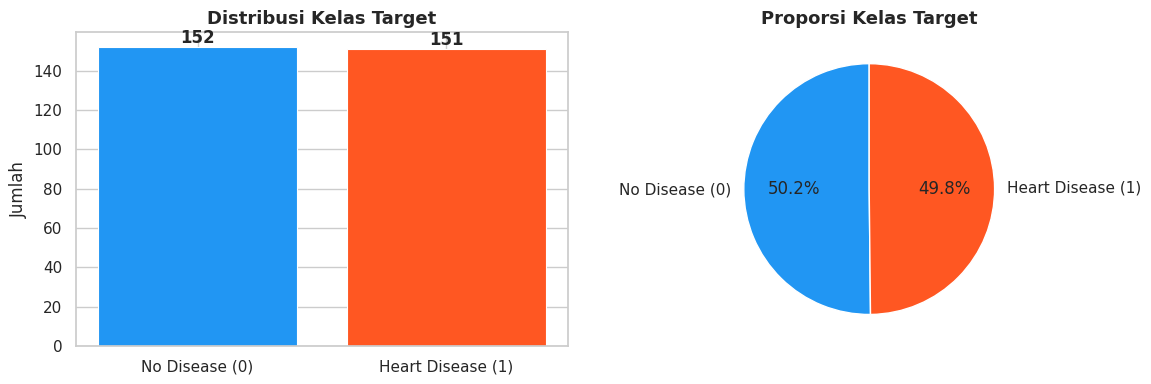

Visualisasi disimpan: eda_01_target_distribution.png


In [66]:
# ── 4.1 Distribusi Target ──────────────────────────────────────
print('=== Distribusi Target (Heart Disease) ===')
target_counts = df['target'].value_counts()
target_pct    = df['target'].value_counts(normalize=True) * 100

for label, count in target_counts.items():
    nama = 'Heart Disease' if label == 1 else 'No Disease'
    print(f'  {label} ({nama}): {count} ({target_pct[label]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = ['#2196F3', '#FF5722']
axes[0].bar(['No Disease (0)', 'Heart Disease (1)'],
             target_counts.values, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Distribusi Kelas Target', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values,
             labels=['No Disease (0)', 'Heart Disease (1)'],
             autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Proporsi Kelas Target', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_01_target_distribution.png', bbox_inches='tight')
plt.show()
print('Visualisasi disimpan: eda_01_target_distribution.png')

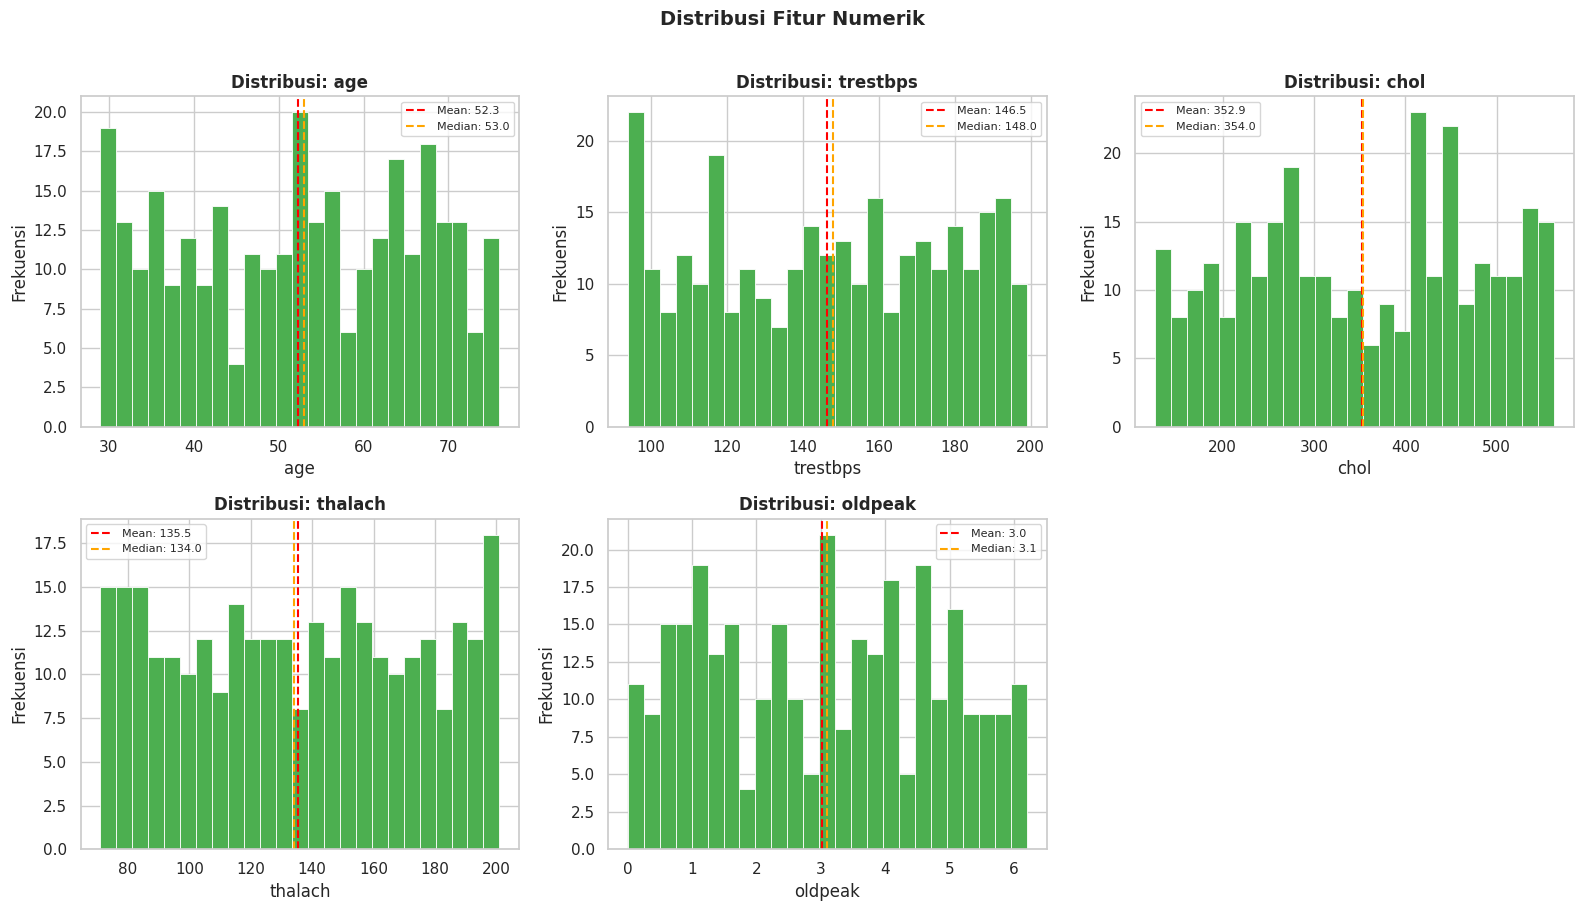

Visualisasi disimpan: eda_02_numerical_distributions.png


In [67]:
# ── 4.2 Distribusi Fitur Numerik ───────────────────────────────
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=25, color='#4CAF50', edgecolor='white', linewidth=0.6)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5,
                     label=f'Mean: {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='orange', linestyle='--', linewidth=1.5,
                     label=f'Median: {df[col].median():.1f}')
    axes[i].set_title(f'Distribusi: {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend(fontsize=8)

# Sembunyikan subplot kosong
axes[5].set_visible(False)

plt.suptitle('Distribusi Fitur Numerik', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_02_numerical_distributions.png', bbox_inches='tight')
plt.show()
print('Visualisasi disimpan: eda_02_numerical_distributions.png')

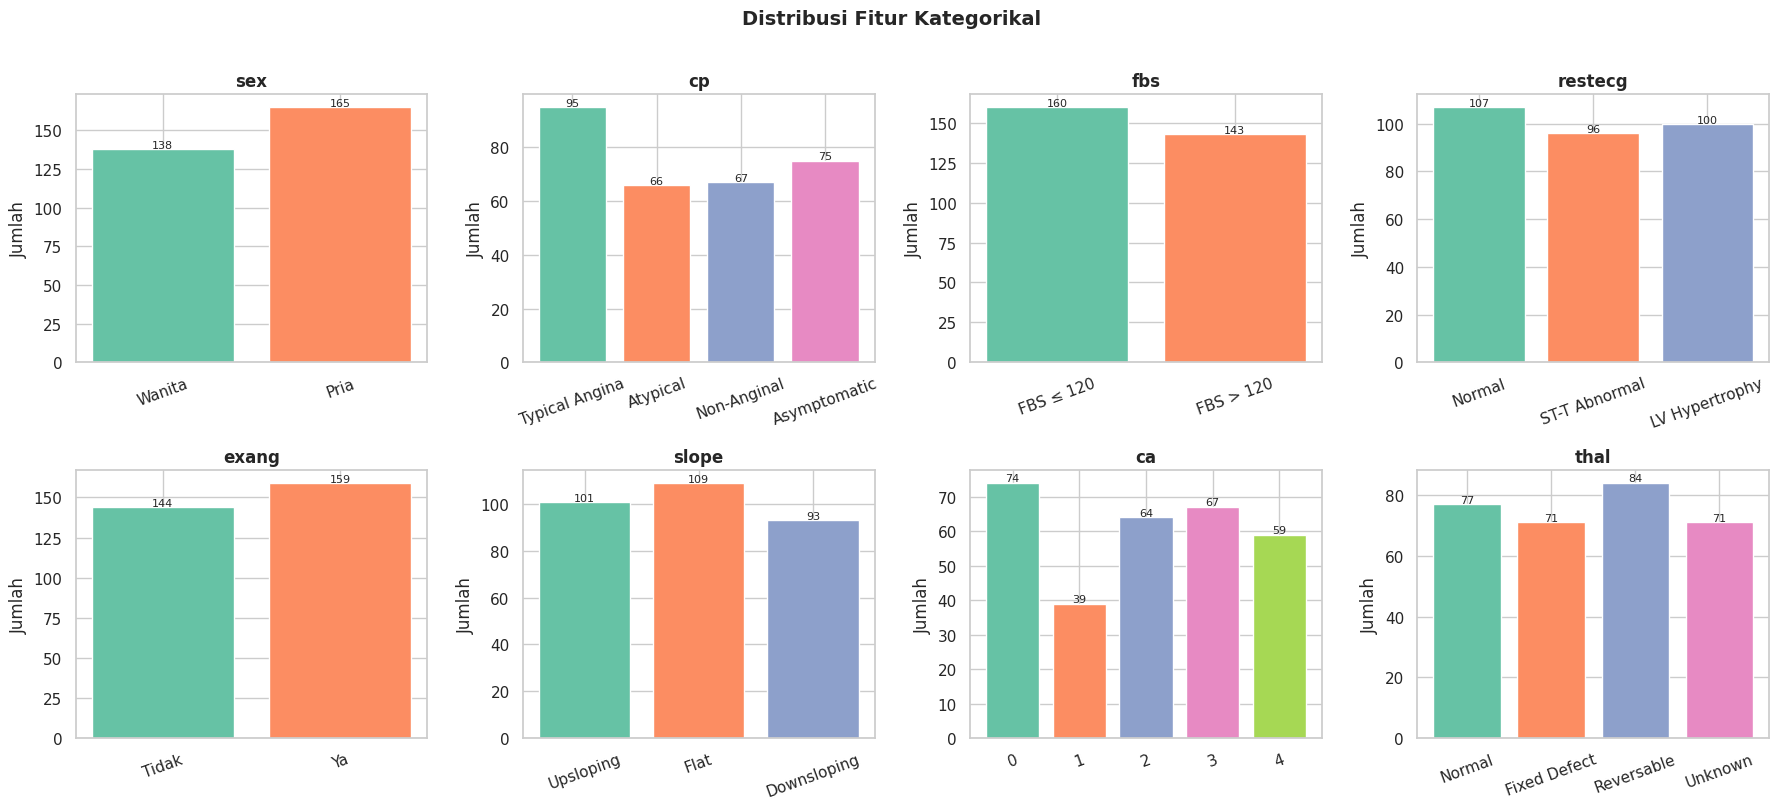

Visualisasi disimpan: eda_03_categorical_distributions.png


In [68]:
# ── 4.3 Distribusi Fitur Kategorikal ──────────────────────────
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
label_maps = {
    'sex':     {0: 'Wanita', 1: 'Pria'},
    'cp':      {0: 'Typical Angina', 1: 'Atypical', 2: 'Non-Anginal', 3: 'Asymptomatic'},
    'fbs':     {0: 'FBS ≤ 120', 1: 'FBS > 120'},
    'restecg': {0: 'Normal', 1: 'ST-T Abnormal', 2: 'LV Hypertrophy'},
    'exang':   {0: 'Tidak', 1: 'Ya'},
    'slope':   {0: 'Upsloping', 1: 'Flat', 2: 'Downsloping'},
    'ca':      {0: '0', 1: '1', 2: '2', 3: '3', 4: '4'},
    'thal':    {0: 'Normal', 1: 'Fixed Defect', 2: 'Reversable', 3: 'Unknown'}
}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
palette = sns.color_palette('Set2')

for i, col in enumerate(categorical_cols):
    vc = df[col].value_counts().sort_index()
    labels_display = [label_maps.get(col, {}).get(k, str(k)) for k in vc.index]
    axes[i].bar(labels_display, vc.values,
                 color=palette[:len(vc)], edgecolor='white')
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_ylabel('Jumlah')
    axes[i].tick_params(axis='x', rotation=20)
    for j, v in enumerate(vc.values):
        axes[i].text(j, v + 0.5, str(v), ha='center', fontsize=8)

plt.suptitle('Distribusi Fitur Kategorikal', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_03_categorical_distributions.png', bbox_inches='tight')
plt.show()
print('Visualisasi disimpan: eda_03_categorical_distributions.png')

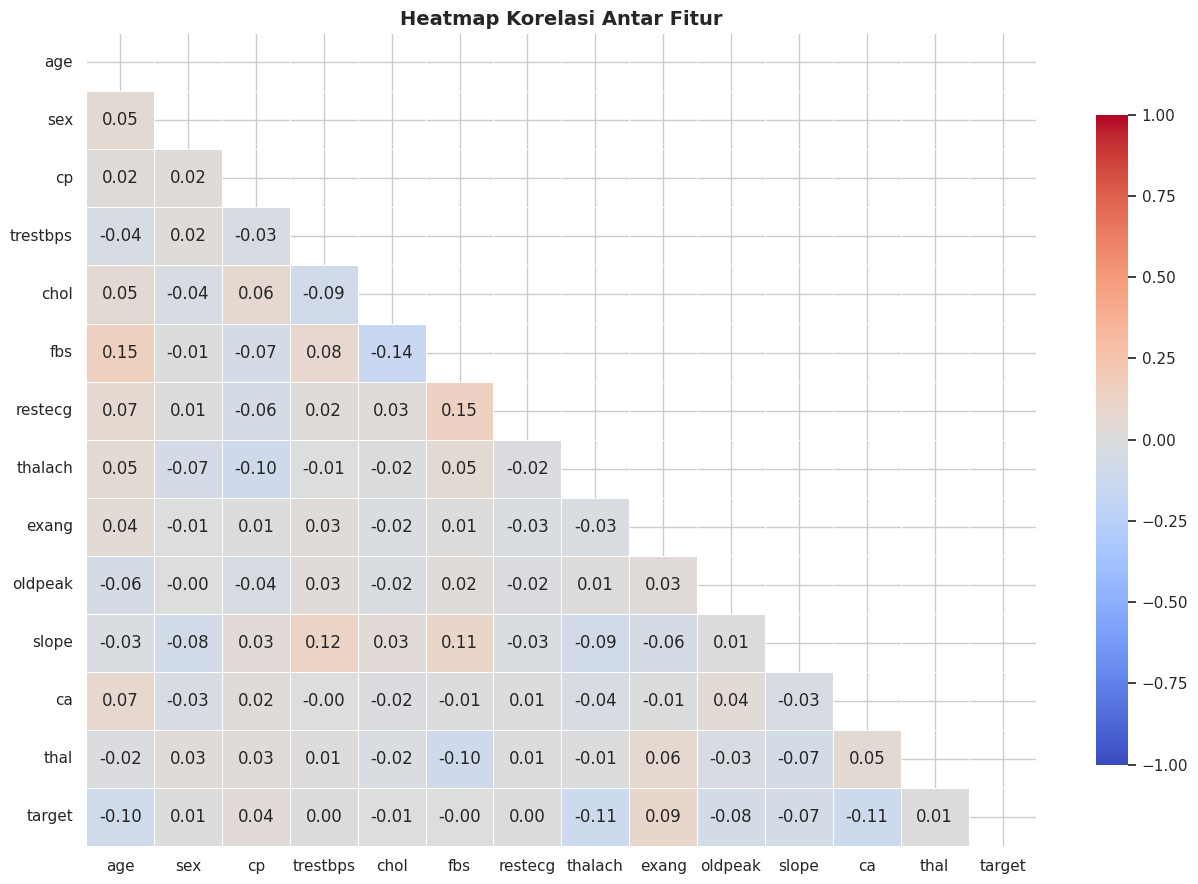


Fitur paling berkorelasi dengan target:
  ca          : 0.1137
  thalach     : 0.1099
  age         : 0.1006
  exang       : 0.0894
  oldpeak     : 0.0767
  slope       : 0.0744
  cp          : 0.0351
  thal        : 0.0104
  sex         : 0.0102
  chol        : 0.0064
  restecg     : 0.0039
  fbs         : 0.0035
  trestbps    : 0.0008
Visualisasi disimpan: eda_04_correlation_heatmap.png


In [69]:
# ── 4.4 Heatmap Korelasi ───────────────────────────────────────
plt.figure(figsize=(13, 9))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_04_correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Fitur paling berkorelasi dengan target
corr_with_target = corr_matrix['target'].drop('target').abs().sort_values(ascending=False)
print('\nFitur paling berkorelasi dengan target:')
for feat, val in corr_with_target.items():
    print(f'  {feat:12s}: {val:.4f}')
print('Visualisasi disimpan: eda_04_correlation_heatmap.png')

In [70]:
# ── 4.5 Deteksi Missing Values ─────────────────────────────────
print('=== Pengecekan Missing Values ===')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print('Tidak ada missing values dalam dataset ini!')
else:
    print(missing_df)
    # Visualisasi
    plt.figure(figsize=(10, 4))
    missing_df['Missing (%)'].plot(kind='bar', color='#FF5722')
    plt.title('Persentase Missing Values per Kolom')
    plt.ylabel('Missing (%)')
    plt.tight_layout()
    plt.savefig('eda_05_missing_values.png', bbox_inches='tight')
    plt.show()

=== Pengecekan Missing Values ===
Tidak ada missing values dalam dataset ini!


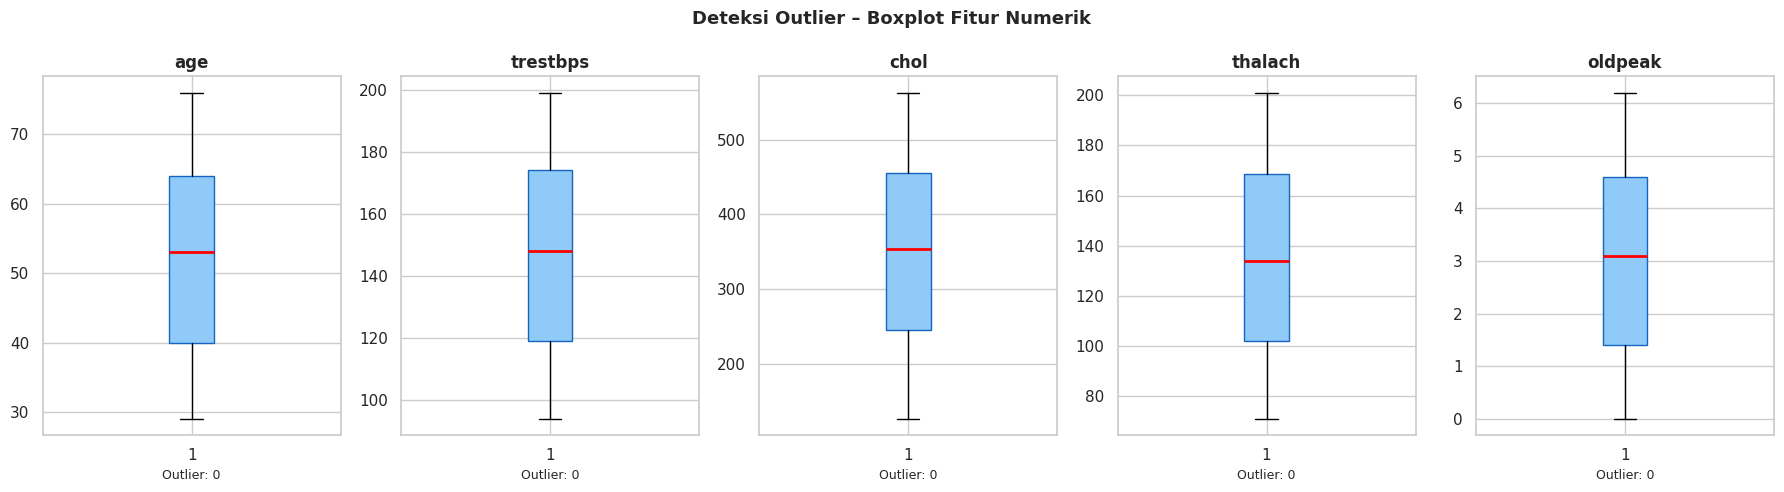

Visualisasi disimpan: eda_05_boxplot_outliers.png


In [71]:
# ── 4.6 Deteksi Outlier (Boxplot) ─────────────────────────────
outlier_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(18, 5))
for i, col in enumerate(outlier_cols):
    bp = axes[i].boxplot(
        df[col].dropna(),
        patch_artist=True,
        boxprops=dict(facecolor='#90CAF9', color='#1565C0'),
        medianprops=dict(color='red', linewidth=2),
        flierprops=dict(marker='o', markerfacecolor='orange', markersize=5)
    )
    axes[i].set_title(col, fontweight='bold')

    # Hitung jumlah outlier
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    axes[i].set_xlabel(f'Outlier: {n_out}', fontsize=9)

plt.suptitle('Deteksi Outlier – Boxplot Fitur Numerik', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_05_boxplot_outliers.png', bbox_inches='tight')
plt.show()
print('Visualisasi disimpan: eda_05_boxplot_outliers.png')

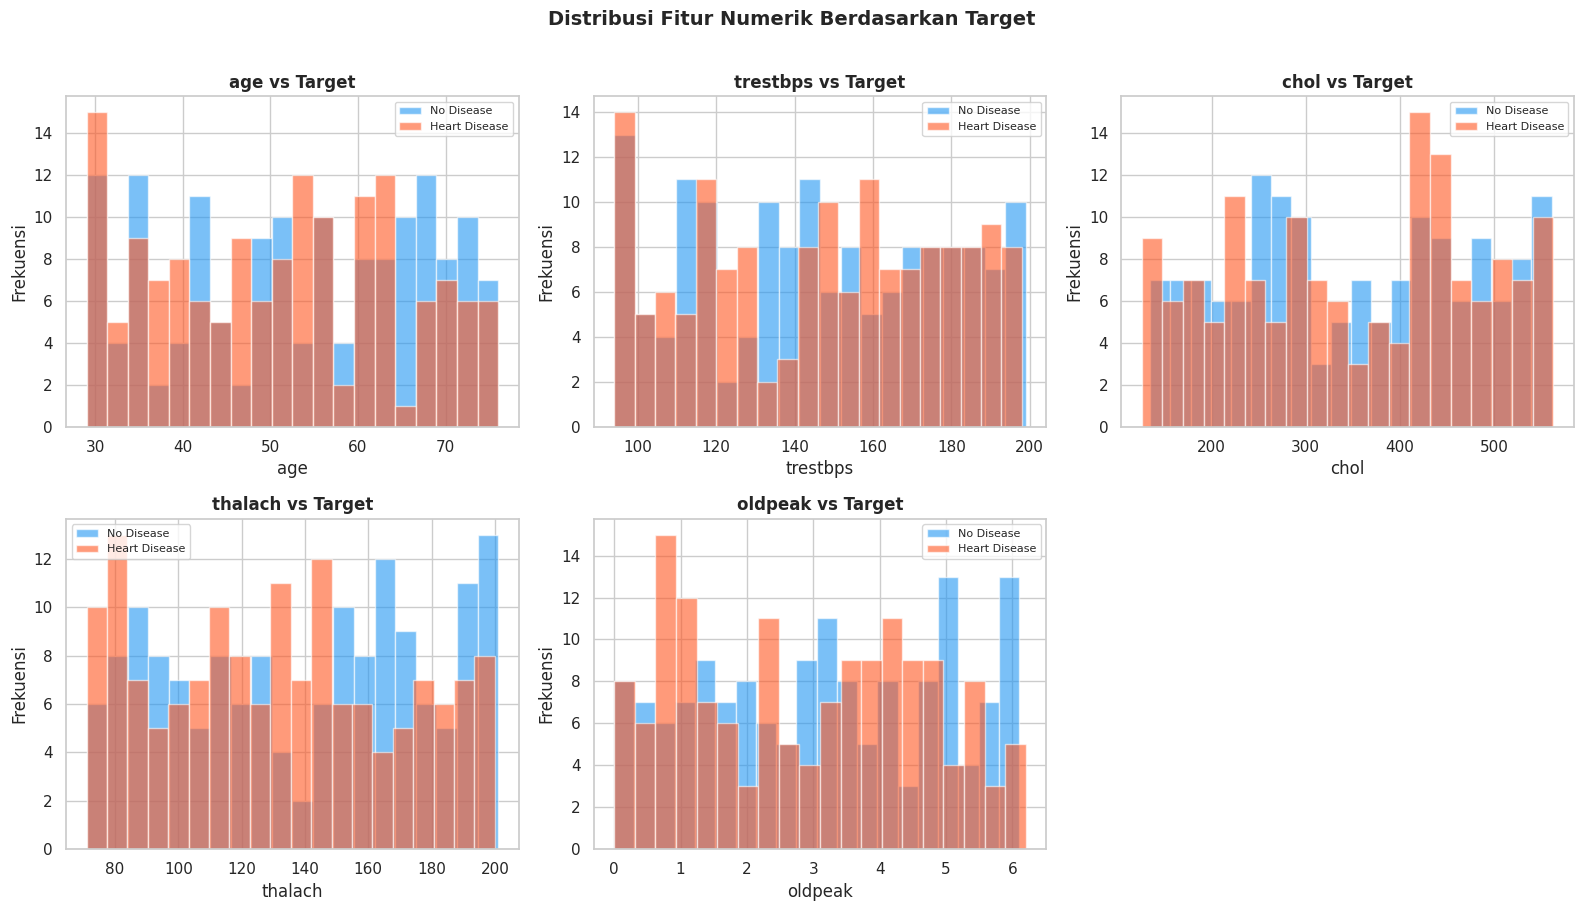

Visualisasi disimpan: eda_06_bivariate_analysis.png


In [72]:
# ── 4.7 Analisis Bivariate: Fitur vs Target ────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
palette_biv = {0: '#2196F3', 1: '#FF5722'}

for i, col in enumerate(numerical_cols):
    for target_val, color in palette_biv.items():
        subset = df[df['target'] == target_val][col]
        axes[i].hist(subset, bins=20, alpha=0.6, color=color,
                      label=('Heart Disease' if target_val == 1 else 'No Disease'),
                      edgecolor='white')
    axes[i].set_title(f'{col} vs Target', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend(fontsize=8)

axes[5].set_visible(False)
plt.suptitle('Distribusi Fitur Numerik Berdasarkan Target', fontsize=14,
              fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_06_bivariate_analysis.png', bbox_inches='tight')
plt.show()
print('Visualisasi disimpan: eda_06_bivariate_analysis.png')

# **5. Data Preprocessing**

Data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Berikut tahapan preprocessing yang akan dilakukan pada dataset Heart Disease UCI:
1. **Menghapus atau Menangani Data Kosong (Missing Values)**
2. **Menghapus Data Duplikat**
3. **Deteksi dan Penanganan Outlier**
4. **Feature Engineering** (Binning & fitur turunan)
5. **Encoding Data Kategorikal** (sudah numerik, verifikasi)
6. **Normalisasi / Standarisasi Fitur**
7. **Pembagian Dataset (Train-Test Split)**
8. **Menyimpan Data yang Sudah Siap Dilatih**

In [73]:
# ── 5.1 Menangani Missing Values ───────────────────────────────
print('=== STEP 1: Handle Missing Values ===')
df_clean = df.copy()

num_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'target' in num_cols:
    num_cols.remove('target')

missing_total = df_clean[num_cols].isnull().sum().sum()
if missing_total > 0:
    imputer = SimpleImputer(strategy='median')
    df_clean[num_cols] = imputer.fit_transform(df_clean[num_cols])
    print(f'   {missing_total} missing values berhasil diimputasi (strategi: median)')
else:
    print(f'   Tidak ada missing values — dataset sudah bersih')

print(f'  Shape setelah handling missing: {df_clean.shape}')

=== STEP 1: Handle Missing Values ===
   Tidak ada missing values — dataset sudah bersih
  Shape setelah handling missing: (303, 14)


In [74]:
# ── 5.2 Menghapus Data Duplikat ────────────────────────────────
print('=== STEP 2: Remove Duplicates ===')
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
df_clean = df_clean.reset_index(drop=True)
removed = before - len(df_clean)

print(f'  Sebelum : {before} baris')
print(f'  Sesudah : {len(df_clean)} baris')
print(f'  Dihapus : {removed} baris duplikat')
print(f'  Proses selesai')

=== STEP 2: Remove Duplicates ===
  Sebelum : 303 baris
  Sesudah : 303 baris
  Dihapus : 0 baris duplikat
  Proses selesai


In [75]:
# ── 5.3 Deteksi dan Penanganan Outlier (IQR Method) ────────────
print('=== STEP 3: Handle Outliers (IQR Method) ===')
outlier_target_cols = ['trestbps', 'chol', 'thalach', 'oldpeak']

def remove_outliers_iqr(df, columns):
    df_out = df.copy()
    total_removed = 0
    for col in columns:
        if col not in df_out.columns:
            continue
        Q1  = df_out[col].quantile(0.25)
        Q3  = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        before_n = len(df_out)
        df_out = df_out[(df_out[col] >= lower) & (df_out[col] <= upper)]
        removed_n = before_n - len(df_out)
        total_removed += removed_n
        if removed_n > 0:
            print(f'  {col:12s} → {removed_n} outlier dihapus '
                  f'[{lower:.1f}, {upper:.1f}]')
    print(f'  Total dihapus  : {total_removed} baris')
    return df_out.reset_index(drop=True)

before_out = len(df_clean)
df_clean = remove_outliers_iqr(df_clean, outlier_target_cols)
print(f'  Shape sebelum : ({before_out}, {df.shape[1]})')
print(f'  Shape sesudah : {df_clean.shape}')
print(f'  Outlier handling selesai')

=== STEP 3: Handle Outliers (IQR Method) ===
  Total dihapus  : 0 baris
  Shape sebelum : (303, 14)
  Shape sesudah : (303, 14)
  Outlier handling selesai


In [76]:
# ── 5.4 Feature Engineering (Binning & Fitur Turunan) ──────────
print('=== STEP 4: Feature Engineering ===')

# Binning: age → age_group
df_clean['age_group'] = pd.cut(
    df_clean['age'],
    bins=[0, 40, 55, 65, 100],
    labels=[0, 1, 2, 3]
).astype(int)
print('   Fitur baru: age_group  (binning usia → 4 kelompok)')
print('       0 = ≤40 thn | 1 = 41–55 | 2 = 56–65 | 3 = >65')

# Fitur turunan: rasio kolesterol per detak jantung
df_clean['chol_thalach_ratio'] = df_clean['chol'] / (df_clean['thalach'] + 1)
print('   Fitur baru: chol_thalach_ratio  (chol / thalach)')

print(f'  Shape setelah feature engineering: {df_clean.shape}')
print(f'  Kolom baru: {[c for c in df_clean.columns if c not in df.columns]}')

=== STEP 4: Feature Engineering ===
   Fitur baru: age_group  (binning usia → 4 kelompok)
       0 = ≤40 thn | 1 = 41–55 | 2 = 56–65 | 3 = >65
   Fitur baru: chol_thalach_ratio  (chol / thalach)
  Shape setelah feature engineering: (303, 16)
  Kolom baru: ['age_group', 'chol_thalach_ratio']


In [77]:
# ── 5.5 Encoding Data Kategorikal ─────────────────────────────
print('=== STEP 5: Encoding Data Kategorikal ===')

# Cek tipe data setelah feature engineering
cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
if cat_cols:
    print(f'  Kolom kategorikal ditemukan: {cat_cols}')
    le = LabelEncoder()
    for col in cat_cols:
        df_clean[col] = le.fit_transform(df_clean[col].astype(str))
        print(f'   {col} → Label Encoded')
else:
    print(' Semua kolom sudah dalam format numerik')
    print(f'     Tipe data: {df_clean.dtypes.value_counts().to_dict()}')

=== STEP 5: Encoding Data Kategorikal ===
 Semua kolom sudah dalam format numerik
     Tipe data: {dtype('int64'): 14, dtype('float64'): 2}


In [78]:
# ── 5.6 Normalisasi / Standarisasi Fitur ───────────────────────
print('=== STEP 6: Normalisasi / Standarisasi Fitur ===')

feature_cols = [c for c in df_clean.columns if c != 'target']
X = df_clean[feature_cols].copy()
y = df_clean['target'].copy()

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=feature_cols
)

print(f'  Metode       : StandardScaler (mean=0, std=1)')
print(f'  Jumlah fitur : {len(feature_cols)}')
print(f'  Fitur        : {feature_cols}')
print()
print('--- Statistik setelah scaling ---')
print(X_scaled.describe().round(4))
print(' Scaling selesai')

=== STEP 6: Normalisasi / Standarisasi Fitur ===
  Metode       : StandardScaler (mean=0, std=1)
  Jumlah fitur : 15
  Fitur        : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'age_group', 'chol_thalach_ratio']

--- Statistik setelah scaling ---
           age      sex       cp  trestbps     chol      fbs  restecg  \
count 303.0000 303.0000 303.0000  303.0000 303.0000 303.0000 303.0000   
mean   -0.0000  -0.0000   0.0000   -0.0000  -0.0000  -0.0000  -0.0000   
std     1.0017   1.0017   1.0017    1.0017   1.0017   1.0017   1.0017   
min    -1.6771  -1.0935  -1.2016   -1.6785  -1.7796  -0.9454  -1.1824   
25%    -0.8842  -1.0935  -1.2016   -0.8794  -0.8423  -0.9454  -1.1824   
50%     0.0528   0.9145  -0.3449    0.0476   0.0087  -0.9454   0.0280   
75%     0.8457   0.9145   0.5117    0.8787   0.8087   1.0578   1.2383   
max     1.7107   0.9145   1.3684    1.6778   1.6480   1.0578   1.2383   

       thalach    exang  

In [79]:
# ── 5.7 Pembagian Dataset (Train-Test Split) ───────────────────
print('=== STEP 7: Train-Test Split ===')

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'  Test size    : 20%')
print(f'  Random state : 42')
print(f'  Stratify     : Ya (menjaga proporsi kelas)')
print()
print(f'  X_train : {X_train.shape}')
print(f'  X_test  : {X_test.shape}')
print(f'  y_train : {y_train.shape}  →  distribusi: {y_train.value_counts().to_dict()}')
print(f'  y_test  : {y_test.shape}  →  distribusi: {y_test.value_counts().to_dict()}')
print(f'  Split selesai')

=== STEP 7: Train-Test Split ===
  Test size    : 20%
  Random state : 42
  Stratify     : Ya (menjaga proporsi kelas)

  X_train : (242, 15)
  X_test  : (61, 15)
  y_train : (242,)  →  distribusi: {1: 121, 0: 121}
  y_test  : (61,)  →  distribusi: {0: 31, 1: 30}
  Split selesai


In [80]:
# ── 5.8 Menyimpan Data yang Sudah Siap Dilatih ─────────────────
print('=== STEP 8: Simpan Preprocessed Data ===')

os.makedirs('heart_preprocessing', exist_ok=True)

# Gabungkan X dan y sebelum disimpan
train_df = X_train.copy()
train_df['target'] = y_train.values

test_df  = X_test.copy()
test_df['target']  = y_test.values

train_df.to_csv('heart_preprocessing/train.csv', index=False)
test_df.to_csv('heart_preprocessing/test.csv',   index=False)

print(f'heart_preprocessing/train.csv  → {len(train_df)} baris, {train_df.shape[1]} kolom')
print(f'heart_preprocessing/test.csv   → {len(test_df)} baris,  {test_df.shape[1]} kolom')
print()
print('  Preview train.csv (5 baris pertama):')
print(train_df.head())
print()
print('=== PREPROCESSING SELESAI ===')
print(f'  Dataset siap dilatih tersedia di folder: heart_preprocessing/')

=== STEP 8: Simpan Preprocessed Data ===
heart_preprocessing/train.csv  → 242 baris, 16 kolom
heart_preprocessing/test.csv   → 61 baris,  16 kolom

  Preview train.csv (5 baris pertama):
        age     sex      cp  trestbps    chol     fbs  restecg  thalach  \
291 -0.3076  0.9145  1.3684    1.3901  1.4519 -0.9454   0.0280  -1.6022   
152  0.4132 -1.0935 -1.2016    1.6458 -1.4894 -0.9454  -1.1824   0.8847   
237 -0.5959 -1.0935  0.5117    0.0795  0.9107 -0.9454   0.0280  -1.5509   
199 -0.0193  0.9145 -1.2016   -1.2310  1.6480 -0.9454  -1.1824  -0.5510   
253 -0.4518  0.9145  1.3684    1.3262  0.8950 -0.9454   0.0280  -0.3203   

      exang  oldpeak  slope      ca    thal  age_group  chol_thalach_ratio  \
291  0.9517  -1.4793 0.0330  0.0045  1.3617    -0.3641              3.0832   
152 -1.0508  -0.2374 1.2834  0.0045 -0.4440     0.5553             -1.3155   
237  0.9517   0.7223 0.0330 -1.3738  1.3617    -0.3641              2.3178   
199  0.9517   0.2707 1.2834 -0.6846 -0.4440    -0.